In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

data = pd.read_csv("../data/CGM.csv", sep=";")

data['timestamp'] = pd.to_datetime(
    data['timestamp'], format='%d.%m.%Y %H:%M')
data = data.sort_values('timestamp')

data.head()

,ID,timestamp,event,event2,gluc_mmol_L,kh_g,Dauer (hh:mm:ss),delta_time_s,Delta_s
0,10,2025-12-04 19:51:00,EGV,NaN,4.7,NaN,NaN,71488,299
1,11,2025-12-04 19:56:00,EGV,NaN,5.2,NaN,NaN,71787,301
2,12,2025-12-04 20:01:00,EGV,NaN,5.2,NaN,NaN,72088,300
3,13,2025-12-04 20:06:00,EGV,NaN,4.8,NaN,NaN,72388,300
4,14,2025-12-04 20:11:00,EGV,NaN,4.9,NaN,NaN,72688,300


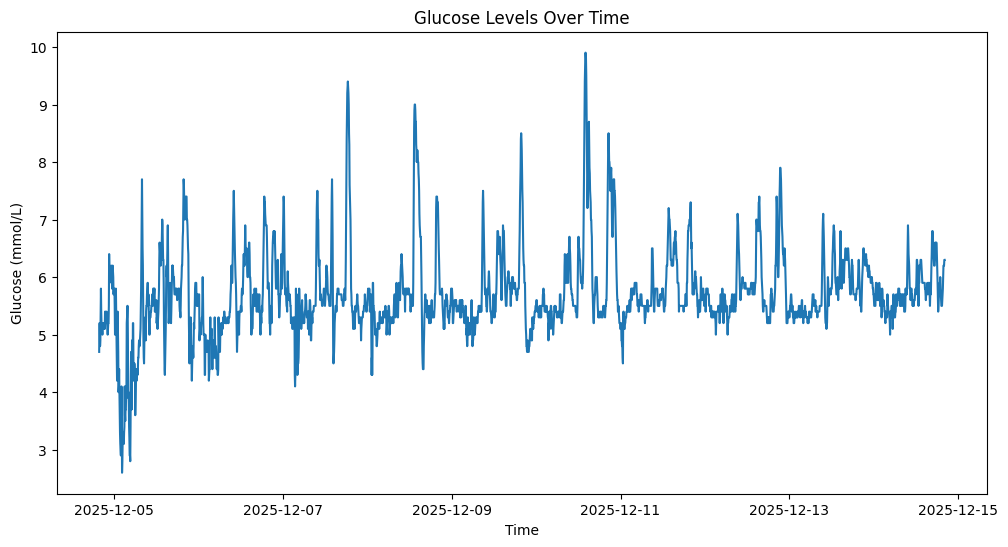

In [4]:
# plot gluc_mmol_L over time
plt.figure(figsize=(12, 6))
sns.lineplot(x="timestamp", y="gluc_mmol_L", data=data)
plt.title("Glucose Levels Over Time")
plt.xlabel("Time")
plt.ylabel("Glucose (mmol/L)")

plt.show()

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

data2 = data = pd.read_csv("../data/GlucoBench_benchmark_dataset.csv", sep=",")

data['timestamp'] = pd.to_datetime(
    data['timestamp'], format='%Y-%m-%d %H:%M:%S')
data = data.sort_values('timestamp')


data2.head()

,user_id,timestamp,glucose,cgm_quality_flag,insulin_bolus,insulin_basal,carbs,meal_type,exercise_steps,exercise_intensity,...,sex,weight,carb_ratio,insulin_sensitivity,timezone,region,glucose_lag_1,glucose_lag_3,glucose_lag_6,glucose_roll_mean_1h
0,U001,2024-09-01 00:00:00,127.0,1,0.0,1.05,0,none,0,none,...,M,79,12,42,America/New_York,USA,NaN,NaN,NaN,127.000000
1,U001,2024-09-01 00:15:00,126.5,1,0.0,0.84,0,none,0,none,...,M,79,12,42,America/New_York,USA,127.0,NaN,NaN,126.750000
2,U001,2024-09-01 00:20:00,126.8,1,0.0,1.19,0,none,0,none,...,M,79,12,42,America/New_York,USA,126.5,NaN,NaN,126.766667
3,U001,2024-09-01 00:25:00,127.2,1,0.0,0.99,0,none,0,none,...,M,79,12,42,America/New_York,USA,126.8,127.0,NaN,126.875000
4,U001,2024-09-01 00:30:00,126.7,1,0.0,1.12,0,none,0,none,...,M,79,12,42,America/New_York,USA,127.2,126.5,NaN,126.840000


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

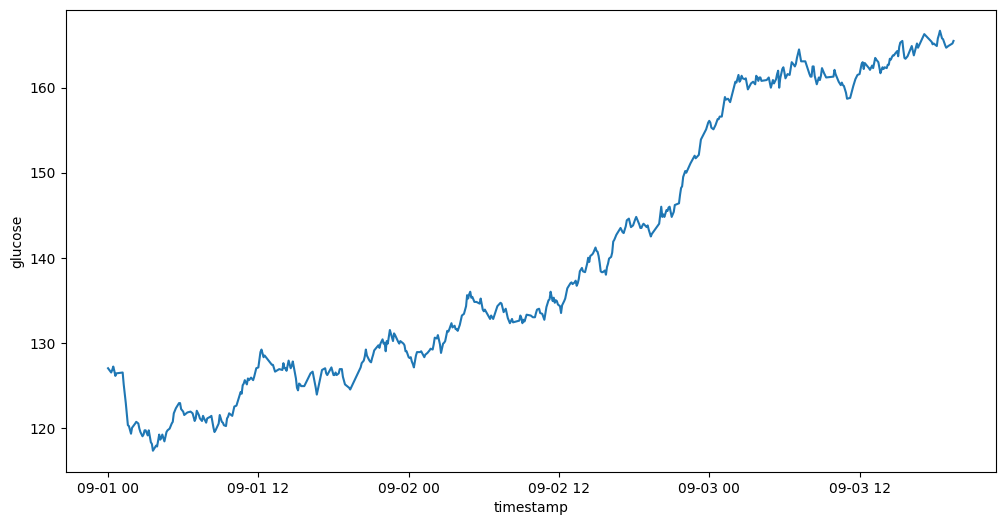

In [3]:
# plot gluc_mmol_L over time
plt.figure(figsize=(12, 6))
sns.lineplot(x="timestamp", y="glucose", data=data2[data2["user_id"] == "U001"].iloc[:500])
sns.lineplot(x="timestamp", y="glucose", data=data2[data2["user_id"] == "U002" and data2["timestamp"] < "2024-09-02"], color="orange")
#sns.barplot(x="timestamp", y="carbs", data=data2[data2["user_id"] == "U001"].iloc[:500], alpha=0.3)
plt.title("Glucose Levels Over Time")
plt.xlabel("Time")
plt.ylabel("Glucose (mmol/L)")

plt.show()

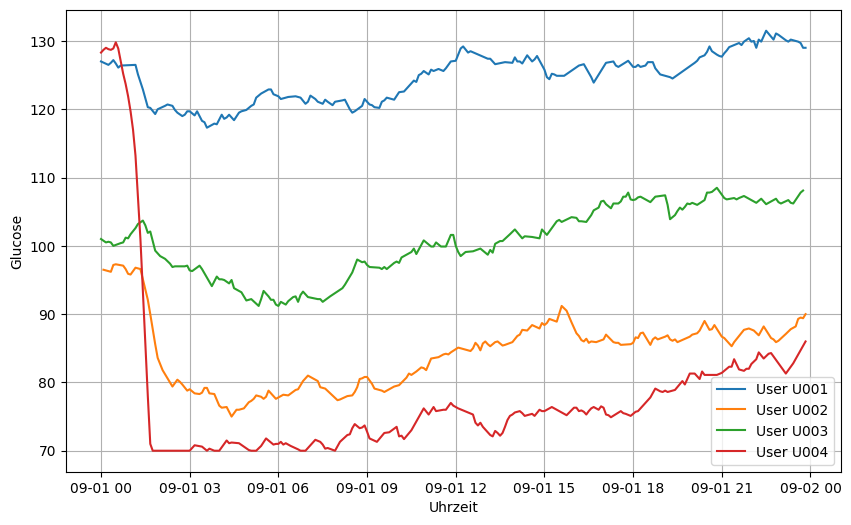

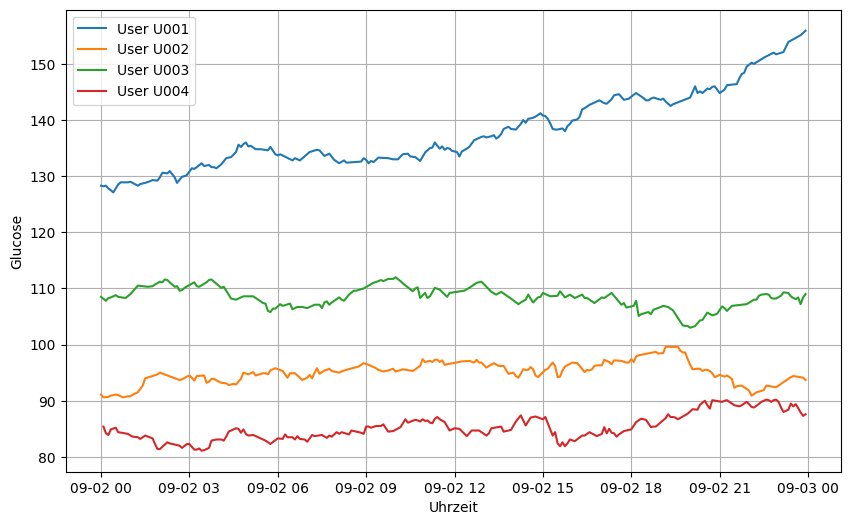

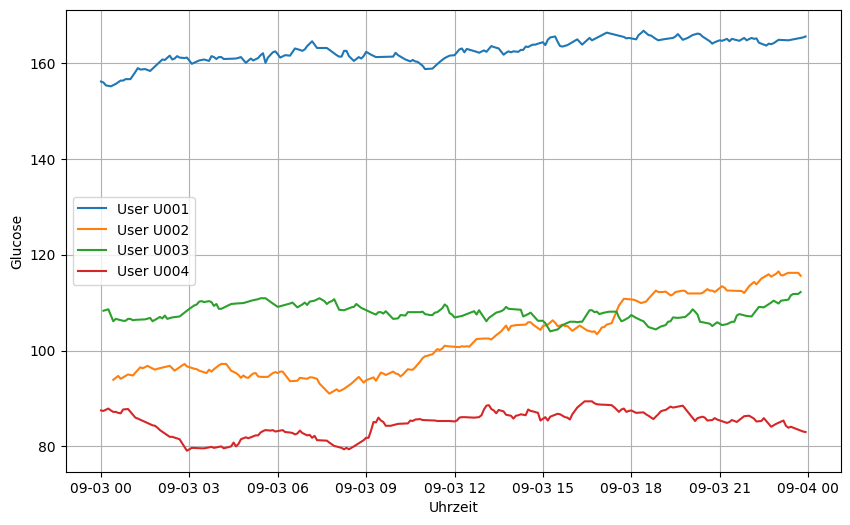

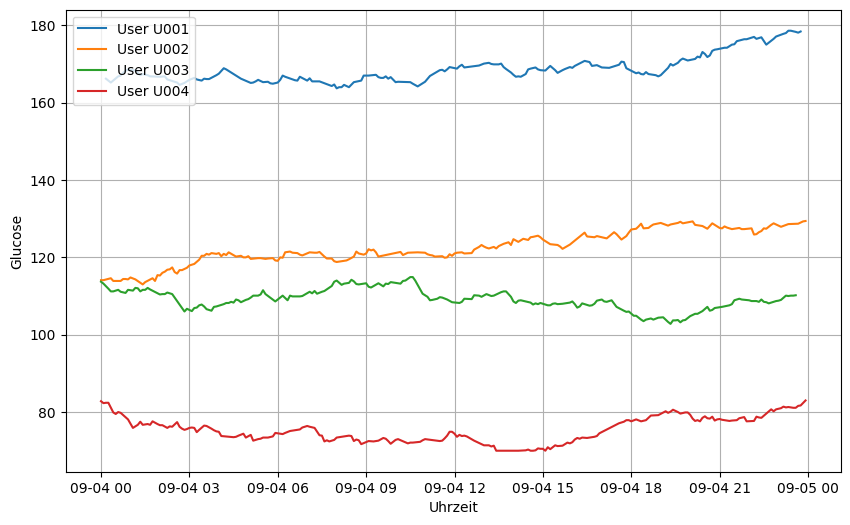

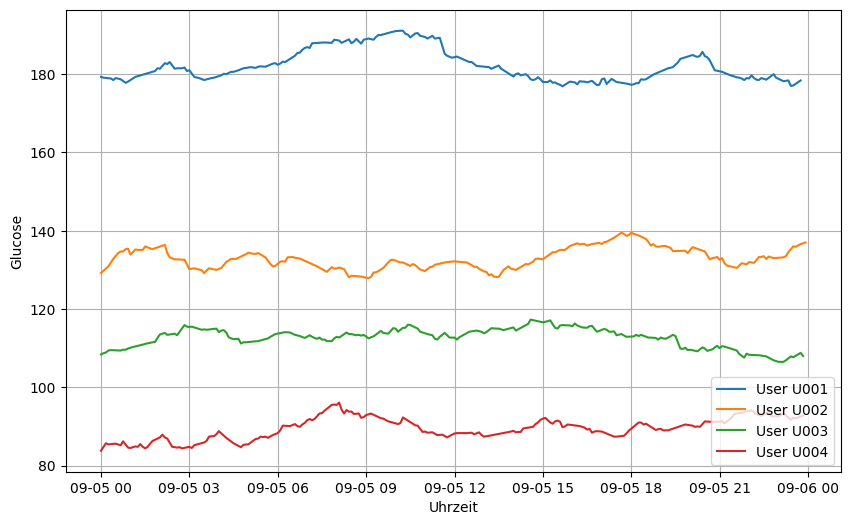

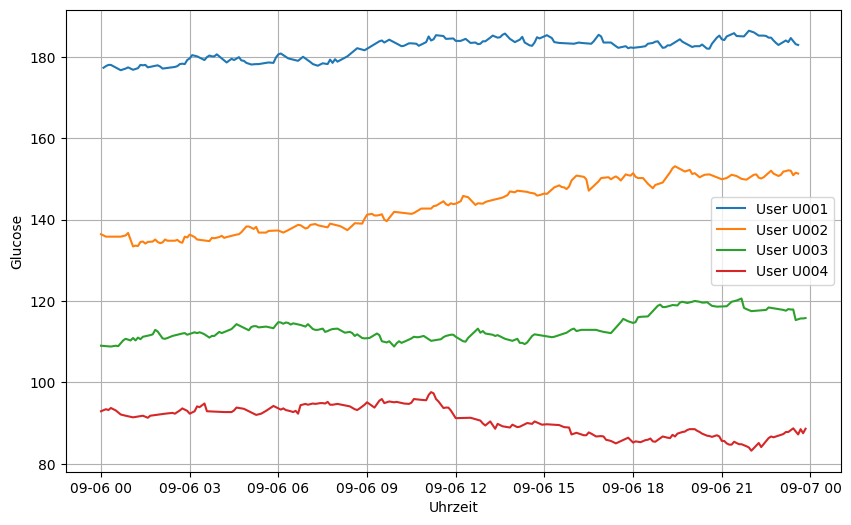

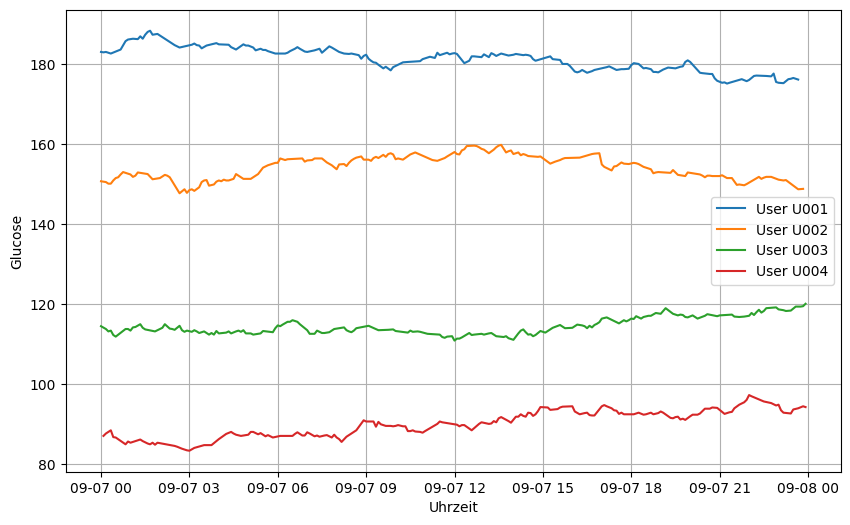

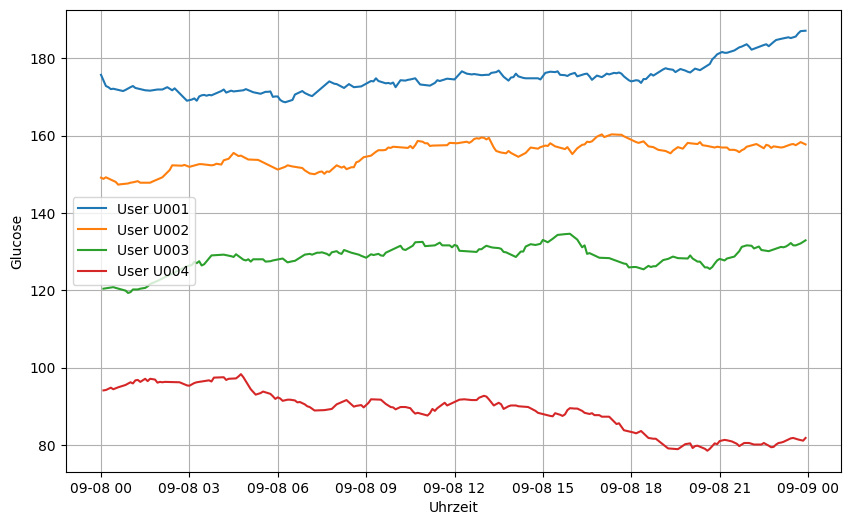

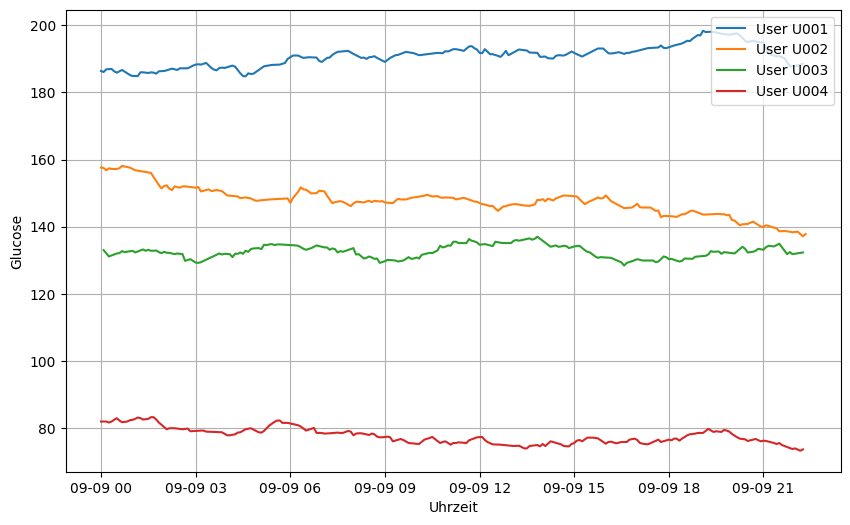

In [17]:
df = data2.copy()

df['timestamp'] = pd.to_datetime(df['timestamp'])

first_day = df['timestamp'].dt.date.min()
days = df['timestamp'].dt.date.unique()
first_4_users = df['user_id'].unique()[:4]

for day in days:
    plot_data = df[(df['timestamp'].dt.date == day) & 
               (df['user_id'].isin(first_4_users))]
    
    plt.figure(figsize=(10, 6))
    for user in first_4_users:
        user_df = plot_data[plot_data['user_id'] == user].sort_values('timestamp')
        plt.plot(user_df['timestamp'], user_df['glucose'], label=f'User {user}')

    plt.xlabel('Uhrzeit')
    plt.ylabel('Glucose')
    plt.legend()
    plt.grid(True)
    plt.show()

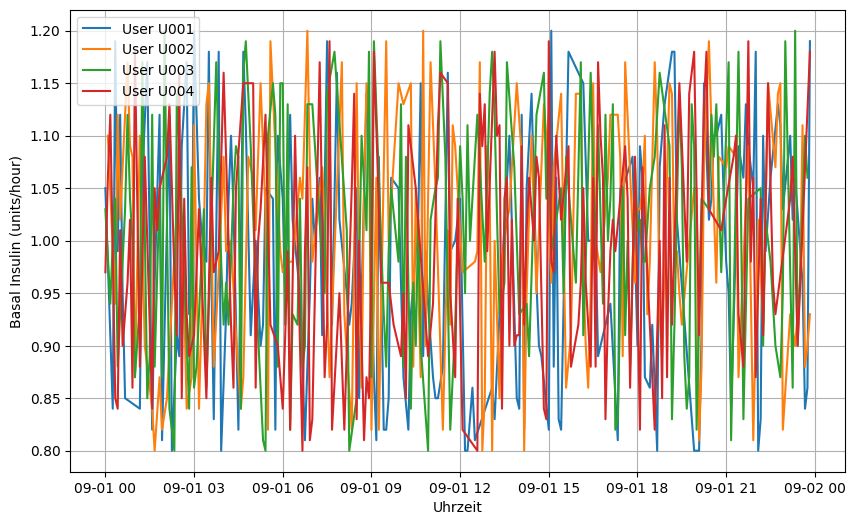

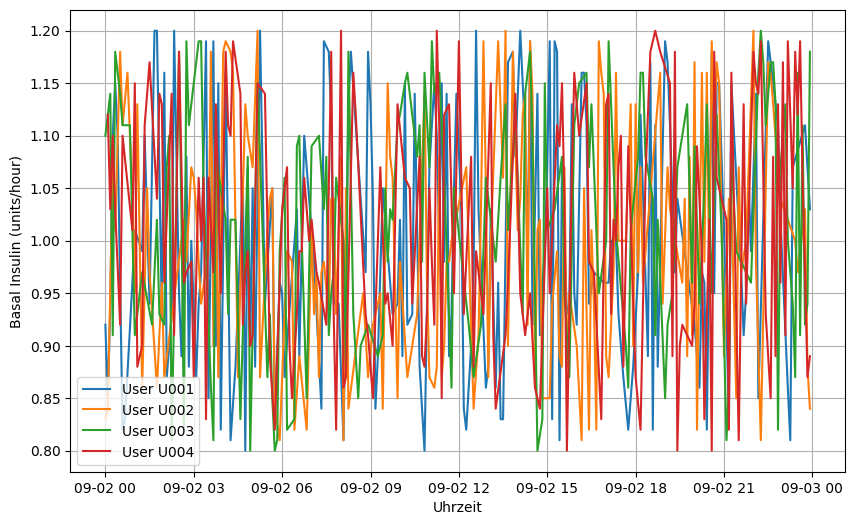

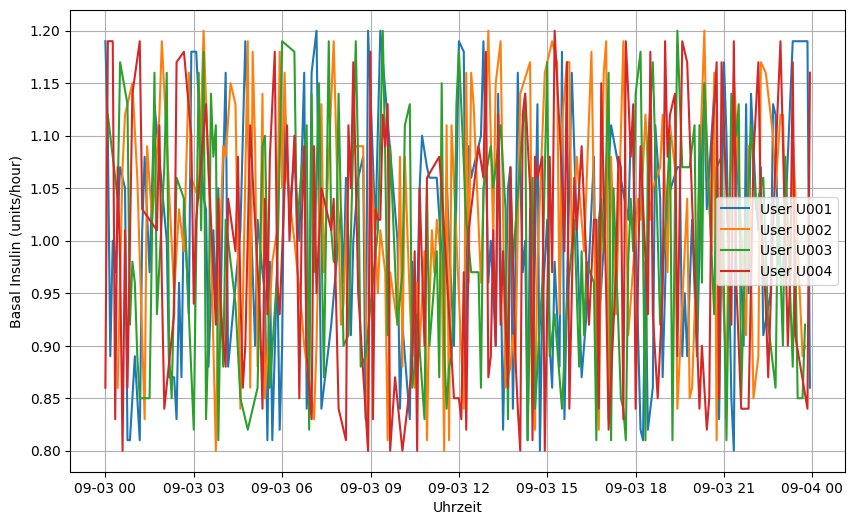

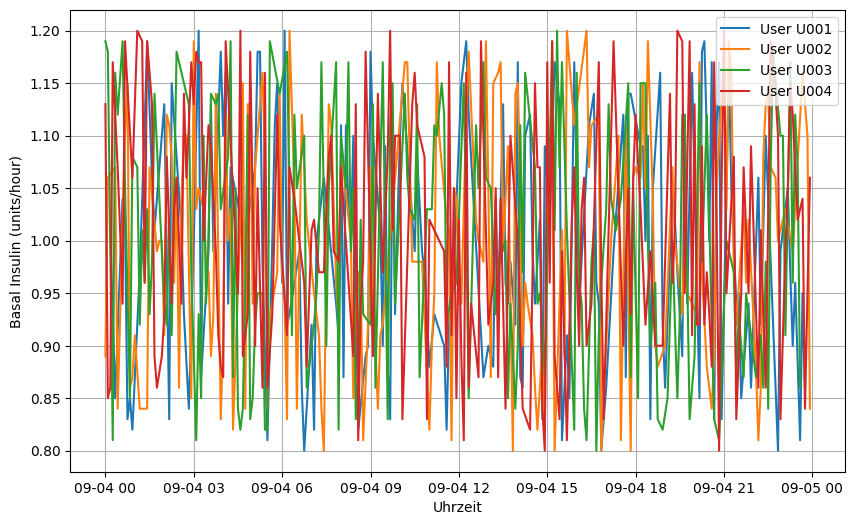

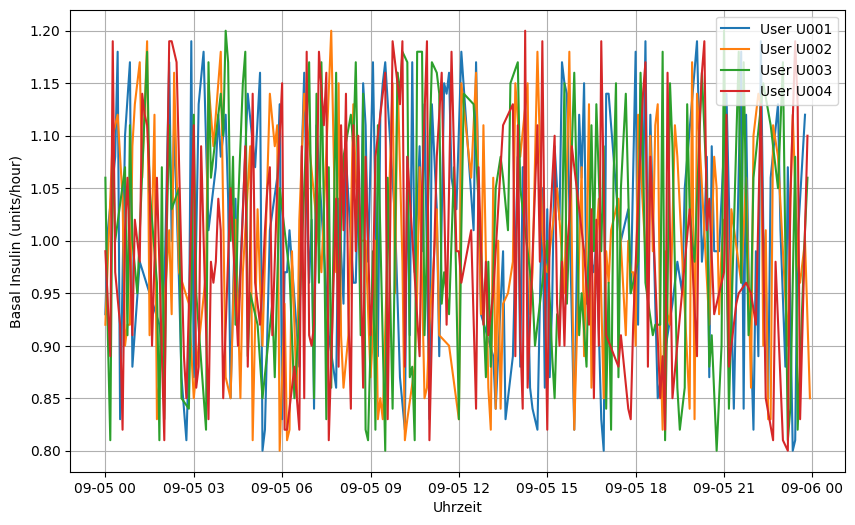

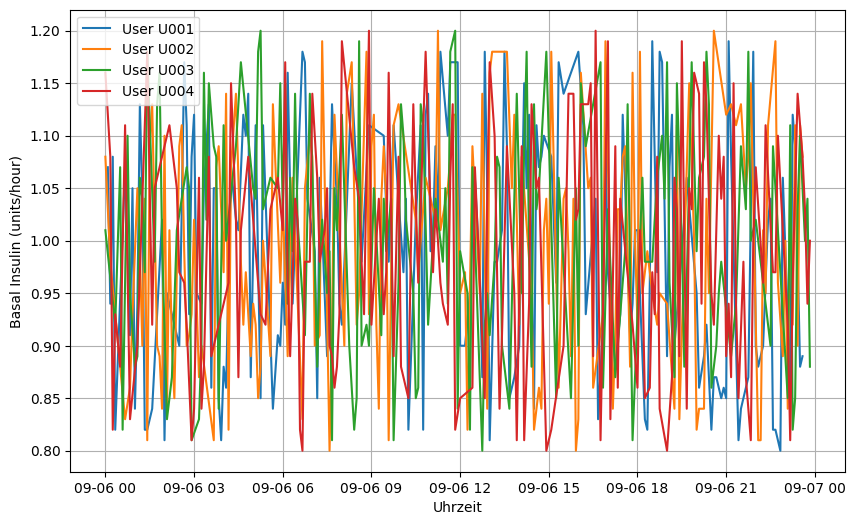

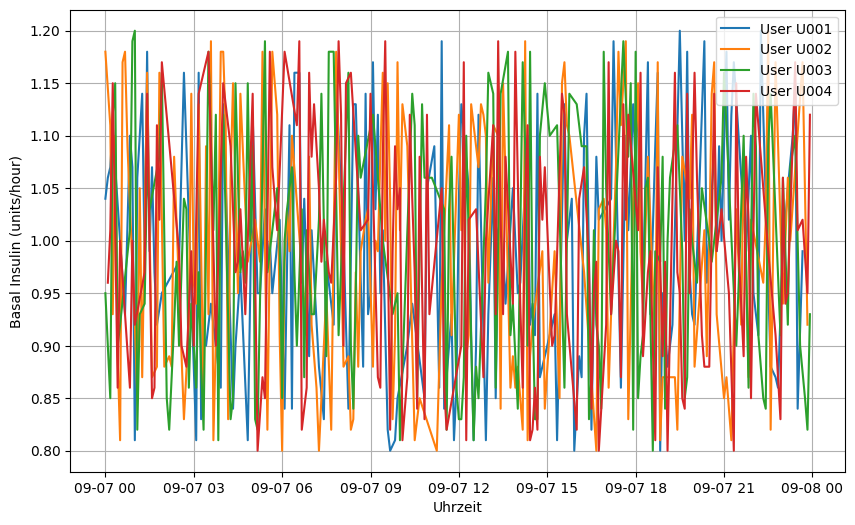

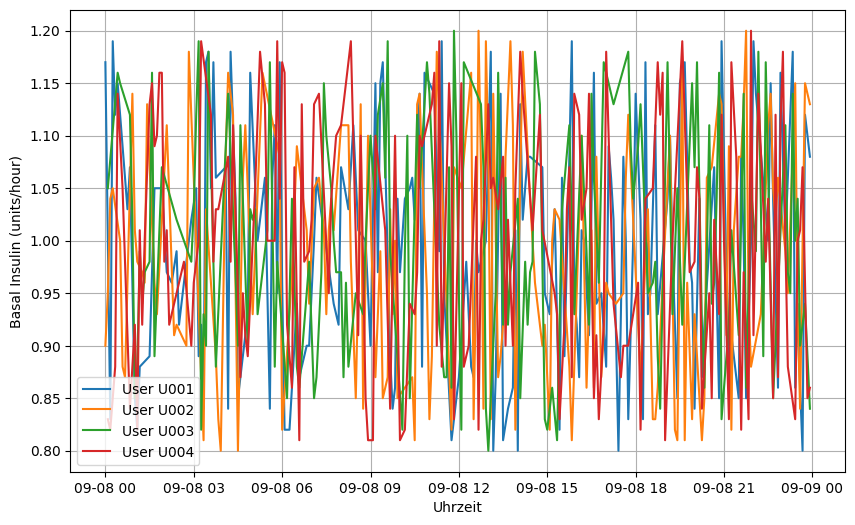

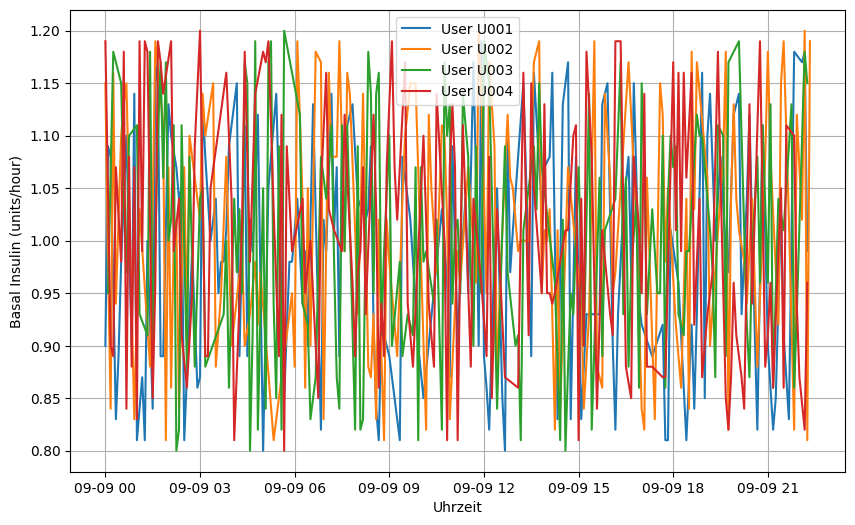

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
data = data2 = pd.read_csv("../data/GlucoBench_benchmark_dataset.csv", sep=",")

df = data2.copy()

df['timestamp'] = pd.to_datetime(df['timestamp'])

first_day = df['timestamp'].dt.date.min()
days = df['timestamp'].dt.date.unique()
first_4_users = df['user_id'].unique()[:4]

for day in days:
    plot_data = df[(df['timestamp'].dt.date == day) & 
               (df['user_id'].isin(first_4_users))]
    
    plt.figure(figsize=(10, 6))
    for user in first_4_users:
        user_df = plot_data[plot_data['user_id'] == user].sort_values('timestamp')
        plt.plot(user_df['timestamp'], user_df['insulin_basal'], label=f'User {user}')

    plt.xlabel('Uhrzeit')
    plt.ylabel('Basal Insulin (units/hour)')
    plt.legend()
    plt.grid(True)
    plt.show()